[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd5-drift/neurips-brain-body/04_pretrain_sjepa_on_normal.ipynb)

# 04. Fold-local S-JEPA training without test exposure

Train the S-JEPA encoder and predictor inside one frozen outer source-video fold. The default loss is **label-free JEPA prediction plus VICReg anti-collapse regularization**. A condition-ordered normal-to-progressive curriculum remains an explicit scheduling prior; it never changes fold membership. The optional group-classification loss is a supervised ablation and is off by default.

**Research use only.** Folder labels are dataset annotations, not diagnoses. Smoke motions test code paths only and have no clinical meaning.


In [1]:
from pathlib import Path
import copy
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import SVG, display


def find_experiment_dir(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"


# Use the same experiment-level configuration contract as notebooks 01-02.
# Existing process variables win, so CI and explicit shell overrides remain
# authoritative while an interactive Jupyter kernel still sees `.env`.
try:
    from dotenv import load_dotenv
    load_dotenv(EXPERIMENT_DIR / ".env", override=False)
except ImportError:
    pass
MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be 'smoke' or 'real'")

ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", EXPERIMENT_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
PROTOCOL_DIR = ARTIFACT_DIR / "evaluation_protocol"
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
for folder in (ARTIFACT_DIR, CHECKPOINT_DIR):
    folder.mkdir(parents=True, exist_ok=True)


def truthy(name, default="0"):
    return os.getenv(name, default).strip().lower() in {"1", "true", "yes", "on"}


def show_tutorial_svg(filename):
    path = EXPERIMENT_DIR / "images" / filename
    if not path.is_file():
        raise FileNotFoundError(path)
    display(SVG(filename=str(path)))


OUTER_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
MODEL_SEED = int(os.getenv("SJEPA_MODEL_SEED", "42"))
if OUTER_FOLD not in range(5):
    raise ValueError("SJEPA_OUTER_FOLD must be one of 0, 1, 2, 3, 4")
random.seed(MODEL_SEED)
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print({
    "mode": MODE,
    "outer_fold": OUTER_FOLD,
    "model_seed": MODEL_SEED,
    "device": str(DEVICE),
    "artifacts": str(ARTIFACT_DIR),
})


{'mode': 'real', 'outer_fold': 0, 'model_seed': 42, 'device': 'cpu', 'artifacts': 'C:\\Users\\alexm\\dev\\alexpose\\experiments\\sjepa\\gavd5-drift\\work\\artifacts\\real'}


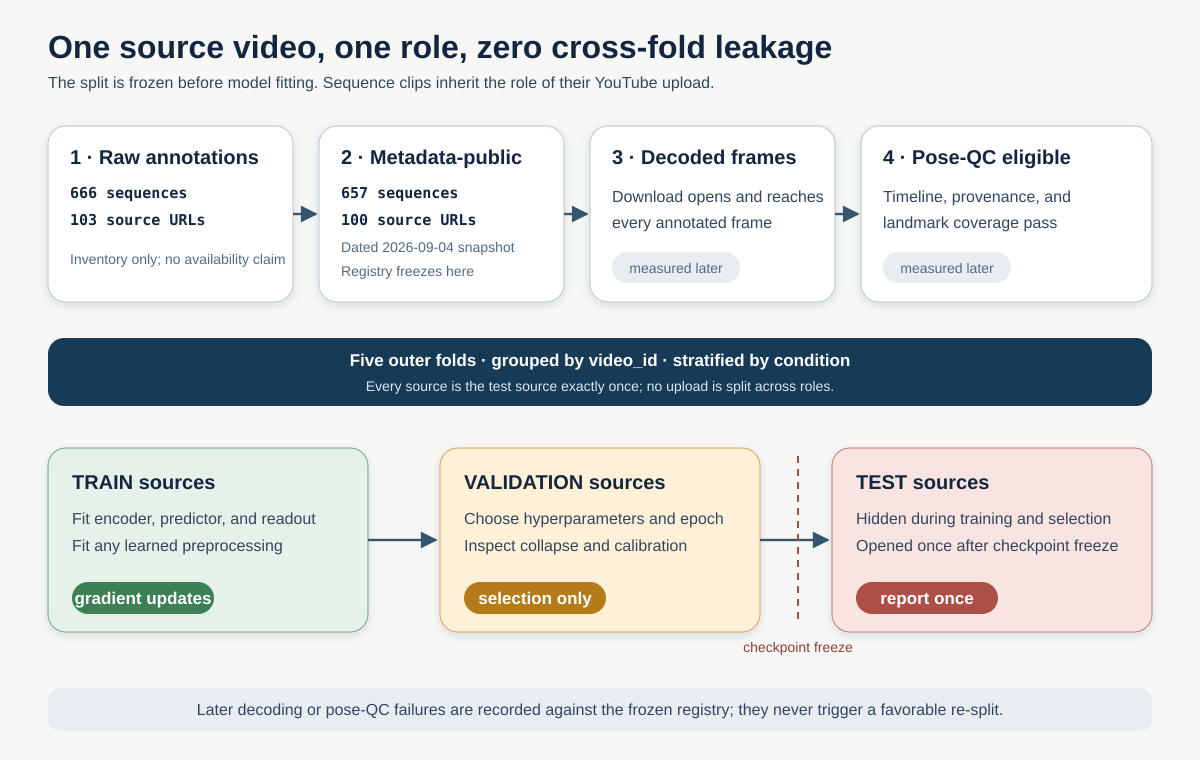

In [2]:
show_tutorial_svg("22_inductive_source_split.svg")


## The isolation contract

The source video—not the excerpt—is the independent unit. `SJEPA_OUTER_FOLD` chooses one of five frozen test folds. For that fold, only pose-QC-eligible **train** sources may update weights; only **validation** sources may choose an epoch; and test tensors are not opened anywhere in this notebook. Metadata for test IDs is retained so the checkpoint can prove what was excluded.

`SJEPA_MODEL_SEED` controls initialization, mask draws, and source sampling. One scientific result therefore requires the full outer-fold × seed grid, not the best-looking run. Aggregate the five untouched test folds only after every modeling choice is frozen.


In [3]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
ROLE_ORDER = ["train", "validation", "test"]


def stable_seed(text):
    return int(hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:8], 16)


def table_sha256(table, columns):
    canonical = table.loc[:, columns].copy().sort_values(columns).reset_index(drop=True)
    payload = canonical.to_csv(index=False, lineterminator="\n").encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def synthetic_metadata(outer_fold=0):
    """Five sources per condition: three train, one validation, one test.

    These rows exercise provenance and isolation. They are not a disease model,
    benchmark sample, or substitute for GAVD.
    """
    rows = []
    test_slot = outer_fold % 5
    validation_slot = (outer_fold + 1) % 5
    for condition in CONDITIONS:
        for source_slot in range(5):
            role = (
                "test" if source_slot == test_slot
                else "validation" if source_slot == validation_slot
                else "train"
            )
            video_id = f"smoke_{condition}_source_{source_slot}"
            for sequence_slot in range(2):
                rows.append({
                    "condition": condition,
                    "video_id": video_id,
                    "sequence_id": f"{video_id}_sequence_{sequence_slot}",
                    "role": role,
                    "pose_qc_eligible": True,
                    "path": "",
                })
    table = pd.DataFrame(rows)
    manifest_sha = table_sha256(table, ["condition", "video_id", "sequence_id"])
    split_sha = table_sha256(table, ["condition", "video_id", "role"])
    return table, {
        "manifest_sha256": manifest_sha,
        "split_sha256": split_sha,
        "split_version": "smoke_source_fixture_v2",
    }


def load_protocol_metadata(outer_fold):
    """Load the frozen registry and fold-specific pose-QC gate.

    This function loads metadata only. Pose tensors are opened later and only for
    the role explicitly requested by the caller.
    """
    if str(NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(NOTEBOOK_DIR))
    from evaluation_protocol import (
        attach_pose_qc_eligibility,
        expand_split,
        manifest_fingerprint,
        split_fingerprint,
        validate_split_registry,
    )

    manifest_path = PROTOCOL_DIR / "eligible_sequence_manifest.csv"
    registry_path = PROTOCOL_DIR / "source_split_registry.csv"
    contract_path = PROTOCOL_DIR / "source_split_contract.json"
    qc_path = PROTOCOL_DIR / f"pose_qc_eligibility_outer_fold_{outer_fold}.csv"
    for path in (manifest_path, registry_path, contract_path, qc_path):
        if not path.is_file():
            raise FileNotFoundError(
                f"Missing {path}. Real mode requires notebooks 01 and 02 for this fold."
            )

    manifest = pd.read_csv(manifest_path)
    registry = pd.read_csv(registry_path)
    contract = json.loads(contract_path.read_text(encoding="utf-8"))
    validate_split_registry(registry, manifest)
    manifest_sha = manifest_fingerprint(manifest)
    split_sha = split_fingerprint(registry)
    if manifest_sha != contract["manifest_sha256"]:
        raise ValueError("Frozen manifest hash differs from source_split_contract.json")
    if split_sha != contract["split_sha256"]:
        raise ValueError("Frozen registry hash differs from source_split_contract.json")

    split_rows = expand_split(manifest, registry, outer_fold)
    qc = pd.read_csv(qc_path)
    table = attach_pose_qc_eligibility(
        split_rows,
        qc,
        outer_fold=outer_fold,
        manifest_sha256=manifest_sha,
        split_sha256=split_sha,
    )
    table = table.loc[table["pose_qc_eligible"]].copy()
    if table.empty:
        raise RuntimeError("No pose-QC-eligible rows are available for this outer fold")
    return table, {
        "manifest_sha256": manifest_sha,
        "split_sha256": split_sha,
        "split_version": str(registry["split_version"].iloc[0]),
    }


def load_metadata(outer_fold):
    return synthetic_metadata(outer_fold) if MODE == "smoke" else load_protocol_metadata(outer_fold)


def synthetic_gait_sequence(condition, sequence_id, frames=36):
    """Deterministic code-path motion; not a physiological simulation."""
    rng = np.random.default_rng(stable_seed(sequence_id))
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    sequence = np.zeros((frames, 33, 4), dtype=np.float32)
    sequence[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        sequence[:, joint, 0], sequence[:, joint, 1] = x, y
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude, lift = amplitude * 0.55, lift * 0.55
    if condition == "myopathic":
        sequence[:, [11, 12], 0] += 0.025 * np.sin(phase)[:, None]
    for ankle, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and ankle == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            sequence[:, knee, 1] -= 0.04
        sequence[:, ankle, 0] += amplitude * wave
        sequence[:, knee, 0] += 0.4 * amplitude * wave
        sequence[:, foot, 0] += amplitude * wave
        sequence[:, ankle, 1] -= lift * np.maximum(wave, 0.0)
    sequence[..., :3] += rng.normal(0.0, 0.0025, sequence[..., :3].shape)
    missing = rng.random(sequence.shape[:2]) < 0.02
    sequence[missing, 3] = 0.0
    sequence[missing, :3] = np.nan
    return sequence


def load_pose_tensor(row, access_log):
    """Load one eligible pose and record the role-level tensor access."""
    role = str(row["role"])
    if MODE == "smoke":
        sequence = synthetic_gait_sequence(row["condition"], row["sequence_id"])
        path_label = f"synthetic://{row['sequence_id']}"
    else:
        candidate = Path(str(row.get("pose_path", "")))
        fallback = POSE_DIR / row["condition"] / f"{row['sequence_id']}.npz"
        path = candidate if candidate.is_file() else fallback
        if not path.is_file():
            raise FileNotFoundError(f"Pose-QC marked eligible but pose cache is missing: {path}")
        data = np.load(path, allow_pickle=False)
        required = {"sequence", "sequence_id", "video_id", "condition", "manifest_sha256", "split_sha256", "split_roles_json"}
        missing_keys = required.difference(data.files)
        if missing_keys:
            raise ValueError(f"Stale pose cache {path}; missing {sorted(missing_keys)}")
        expected = {
            "sequence_id": str(row["sequence_id"]),
            "video_id": str(row["video_id"]),
            "condition": str(row["condition"]),
            "manifest_sha256": MANIFEST_SHA256,
            "split_sha256": SPLIT_SHA256,
        }
        for key, value in expected.items():
            if str(data[key].item()) != value:
                raise ValueError(f"{path}: {key} does not match frozen protocol")
        role_map = json.loads(str(data["split_roles_json"].item()))
        if role_map.get(str(OUTER_FOLD)) != role:
            raise ValueError(f"{path}: role map does not match outer fold {OUTER_FOLD}")
        sequence = data["sequence"]
        path_label = str(path)
    access_log.append({
        "role": role,
        "video_id": str(row["video_id"]),
        "sequence_id": str(row["sequence_id"]),
        "path": path_label,
    })
    return sequence


In [4]:
import math
from torch import nn
from torch.nn import functional as F


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T,33,4], got {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    valid = (visibility >= 0.45) & np.isfinite(sequence[..., :3]).all(axis=-1)
    xyz = sequence[..., :3]
    hips = np.nanmean(xyz[:, [23, 24]], axis=1)
    fallback = np.nanmedian(hips, axis=0)
    fallback = np.nan_to_num(fallback, nan=0.0)
    hips = np.where(np.isfinite(hips), hips, fallback)
    xyz = xyz - hips[:, None, :]
    shoulder = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    scale = np.nanmedian(np.maximum(shoulder, hip))
    scale = float(scale) if np.isfinite(scale) and scale > 1e-6 else 1.0
    xyz = np.nan_to_num(xyz / scale, nan=0.0, posinf=0.0, neginf=0.0)
    xyz = temporal_resize(xyz, frames).astype(np.float32)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return xyz, valid


class SkeletonEncoder(nn.Module):
    def __init__(self, frames=32, segment_length=4, embed_dim=32, depth=1, heads=4):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.segment_length = frames, segment_length
        self.segments, self.embed_dim = frames // segment_length, embed_dim
        self.patch = nn.Linear(3, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(33, embed_dim) * 0.02)
        self.mask_token = nn.Parameter(torch.zeros(embed_dim))
        layer = nn.TransformerEncoderLayer(
            embed_dim, heads, embed_dim * 2, dropout=0.0,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch = len(x)
        return x.reshape(batch, self.segments, self.segment_length, 33, 3).mean(dim=2)

    def patch_valid(self, valid):
        batch = len(valid)
        return valid.reshape(batch, self.segments, self.segment_length, 33).all(dim=2)

    def forward(self, x, hidden=None):
        patches = self.patchify(x)
        tokens = self.patch(patches)
        if hidden is not None:
            tokens = torch.where(hidden[..., None], self.mask_token, tokens)
        tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
        shape = tokens.shape
        tokens = self.blocks(tokens.reshape(shape[0], shape[1] * shape[2], shape[3]))
        return self.norm(tokens).reshape(shape)


class SJEPAProjector(nn.Module):
    def __init__(self, embed_dim=32, project_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, project_dim))

    def forward(self, x):
        return self.net(x)


class SJEPAPredictor(nn.Module):
    def __init__(self, segments, embed_dim=32):
        super().__init__()
        self.position = nn.Parameter(torch.randn(segments, 33, embed_dim) * 0.02)
        self.net = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Linear(embed_dim * 2, embed_dim))

    def forward(self, context_tokens, visible):
        weight = visible[..., None].float()
        context = (context_tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)
        return self.net(context[:, None, None, :] + self.position[None])


def model_components(config, device=DEVICE):
    online = SkeletonEncoder(**config).to(device)
    target = copy.deepcopy(online).to(device).eval()
    for parameter in target.parameters():
        parameter.requires_grad_(False)
    predictor = SJEPAPredictor(online.segments, config["embed_dim"]).to(device)
    projector = SJEPAProjector(config["embed_dim"], config["embed_dim"]).to(device)
    group_head = nn.Linear(config["embed_dim"], len(CONDITIONS)).to(device)
    return online, target, predictor, projector, group_head


def uniform_target_mask(valid_patch, fraction, generator):
    eligible_joint = torch.zeros(33, dtype=torch.bool, device=valid_patch.device)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.flatten(1).sum(1)
    if int(counts.min()) < 2:
        raise ValueError("Every pose-QC sample needs at least two eligible target tokens")
    count = max(1, min(int(counts.min()) - 1, int(math.floor(int(counts.min()) * fraction))))
    mask = torch.zeros_like(eligible)
    for index in range(len(mask)):
        candidates = torch.nonzero(eligible[index].flatten(), as_tuple=False).flatten().cpu().numpy()
        chosen = generator.choice(candidates, size=count, replace=False)
        mask[index].view(-1)[torch.as_tensor(chosen, device=mask.device)] = True
    return mask


def masked_pool(tokens, valid):
    weight = valid[..., None].float()
    return (tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)


def vicreg_terms(projected):
    if len(projected) < 2:
        zero = projected.sum() * 0.0
        return zero, zero
    centered = projected - projected.mean(0)
    std = torch.sqrt(projected.var(0, unbiased=False) + 1e-4)
    variance = F.relu(1.0 - std).mean()
    covariance = centered.T @ centered / max(len(projected) - 1, 1)
    covariance = covariance - torch.diag(torch.diag(covariance))
    return variance, covariance.square().sum() / projected.shape[1]


def weighted_stats(tokens, valid):
    weight = valid[..., None].float()
    denom = weight.sum((1, 2)).clamp_min(1.0)
    mean = (tokens * weight).sum((1, 2)) / denom
    var = ((tokens - mean[:, None, None]) ** 2 * weight).sum((1, 2)) / denom
    return mean, torch.sqrt(var + 1e-6)


@torch.no_grad()
def embed_prepared(target_encoder, prepared, batch_size=32):
    target_encoder.eval()
    chunks = []
    for start in range(0, len(prepared), batch_size):
        batch = prepared[start:start + batch_size]
        xyz = torch.as_tensor(np.stack([r["xyz"] for r in batch]), device=DEVICE)
        valid = torch.as_tensor(np.stack([r["valid"] for r in batch]), device=DEVICE)
        tokens = target_encoder(xyz)
        patch_valid = target_encoder.patch_valid(valid)
        overall = weighted_stats(tokens, patch_valid)
        neuro = weighted_stats(tokens[:, :, MASK_KEYPOINTS], patch_valid[:, :, MASK_KEYPOINTS])
        chunks.append(torch.cat([*overall, *neuro], dim=1).cpu().numpy())
    return np.concatenate(chunks, axis=0)


## Lock IDs before materializing tensors

Real mode reads notebook 01's hashed manifest/registry and notebook 02's fold-specific pose-QC eligibility. QC failures remain exclusions; they never trigger a new split. The assertions below are fatal because a single shared source would make the inductive claim false.

Notebook 01's `pose_qc_eligible` value is deliberately only a placeholder. The fold-local notebook 02 ledger is authoritative: its manifest/split hashes and role are validated, its pose path is attached as `pose_path`, and decoded-ineligible or inventory-extra rows remain excluded. This explicit namespace prevents pandas `_x`/`_y` collisions with download fields such as `path`.


## How to read the progress display

The display separates split-contract validation, train/validation tensor
materialization, model setup, curriculum optimization, and final checkpoint
persistence. During optimization it reports completed epochs across all five
curriculum stages. ETA adapts to completed stages and can move sharply because
data loading, epochs, and checkpoint writes have different costs. Progress is
observational and never reads the sealed test tensors.


In [5]:
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

training_progress = NotebookTaskProgress(
    'Fold-local curriculum training progress',
    "stage",
    refresh_seconds=0.5,
)
training_progress.start(5, profile=MODE,
    note='Epoch progress never opens outer-test tensors.')

with training_progress.unit(1, "Validate split identity and role separation"):
    metadata, protocol = load_metadata(OUTER_FOLD)
    MANIFEST_SHA256 = protocol["manifest_sha256"]
    SPLIT_SHA256 = protocol["split_sha256"]
    SPLIT_VERSION = protocol["split_version"]

    role_video_ids = {
        role: sorted(metadata.loc[metadata["role"].eq(role), "video_id"].astype(str).unique())
        for role in ROLE_ORDER
    }
    role_sequence_ids = {
        role: sorted(metadata.loc[metadata["role"].eq(role), "sequence_id"].astype(str).unique())
        for role in ROLE_ORDER
    }
    for left_index, left in enumerate(ROLE_ORDER):
        for right in ROLE_ORDER[left_index + 1:]:
            overlap = set(role_video_ids[left]) & set(role_video_ids[right])
            assert not overlap, f"source leakage between {left} and {right}: {sorted(overlap)}"
    if any(not role_video_ids[role] for role in ROLE_ORDER):
        raise RuntimeError(f"Every role needs pose-QC-eligible sources: {role_video_ids}")

    display(
        metadata.groupby(["role", "condition"])
        .agg(sequences=("sequence_id", "nunique"), sources=("video_id", "nunique"))
    )
    print({"manifest_sha256": MANIFEST_SHA256, "split_sha256": SPLIT_SHA256})


sequences  sources
role       condition                        
test       cerebralpalsy         14        2
           myopathic             37        6
           normal                56        7
           parkinsons             9        2
           stroke                15        3
train      cerebralpalsy         38        6
           myopathic            111       17
           normal               156       18
           parkinsons            28        7
           stroke                44       11
validation cerebralpalsy          8        2
           myopathic             35        5
           normal                64        5
           parkinsons             9        2
           stroke                15        4

{'manifest_sha256': '7fd559e5105b11011a3e5c194b7ccc29729c56491c424745834df39884123b5a', 'split_sha256': 'ff3518b87b1d1fa7d95efb1aea1711773137a21699967cb8015edb8d845ccbe1'}


## Source-balanced sampling and objective

Uniform sequence sampling would let a long YouTube upload dominate. Each update instead samples a train **source uniformly**, then one sequence from that source. Labels do not enter the default loss. The curriculum's condition order is nevertheless an inductive scheduling choice and must be reported.

For hidden, valid tokens on the 12-joint neurologic whitelist, JEPA matches predictor output to a stop-gradient EMA target. VICReg variance and covariance terms discourage collapse. Set `SJEPA_ENABLE_GROUP_LOSS=1` only for the explicitly named supervised ablation; it adds a condition-classification term and produces a differently named checkpoint.


In [6]:
with training_progress.unit(2, "Materialize train and validation tensors"):
    FRAMES = int(os.getenv("SJEPA_FRAMES", "16" if MODE == "smoke" else "64"))
    MODEL_CONFIG = {
        "frames": FRAMES,
        "segment_length": 4,
        "embed_dim": int(os.getenv("SJEPA_EMBED_DIM", "16" if MODE == "smoke" else "64")),
        "depth": int(os.getenv("SJEPA_DEPTH", "1" if MODE == "smoke" else "2")),
        "heads": int(os.getenv("SJEPA_HEADS", "4")),
    }
    GROUP_ABLATION = truthy("SJEPA_ENABLE_GROUP_LOSS", "0")
    OBJECTIVE_NAME = "jepa_vicreg_group_ablation" if GROUP_ABLATION else "jepa_vicreg"
    OBJECTIVE = {
        "name": OBJECTIVE_NAME,
        "label_free": not GROUP_ABLATION,
        "jepa_weight": 1.0,
        "vicreg_variance_weight": 0.10,
        "vicreg_covariance_weight": 0.01,
        "group_loss_enabled": GROUP_ABLATION,
        "group_loss_weight": 0.10 if GROUP_ABLATION else 0.0,
    }
    CURRICULUM = [
        {"stage": 0, "name": "normal_only", "condition": "normal", "conditions_seen": ["normal"]},
        {"stage": 1, "name": "add_parkinsons", "condition": "parkinsons", "conditions_seen": CONDITIONS[:2]},
        {"stage": 2, "name": "add_stroke", "condition": "stroke", "conditions_seen": CONDITIONS[:3]},
        {"stage": 3, "name": "add_myopathic", "condition": "myopathic", "conditions_seen": CONDITIONS[:4]},
        {"stage": 4, "name": "add_cerebralpalsy", "condition": "cerebralpalsy", "conditions_seen": CONDITIONS[:5]},
    ]
    EPOCHS_PER_STAGE = int(os.getenv("SJEPA_EPOCHS_PER_STAGE", "1" if MODE == "smoke" else "20"))
    STEPS_PER_EPOCH = int(os.getenv("SJEPA_STEPS_PER_EPOCH", "2" if MODE == "smoke" else "100"))
    BATCH_SIZE = int(os.getenv("SJEPA_BATCH_SIZE", "8" if MODE == "smoke" else "32"))
    MASK_FRACTION = float(os.getenv("SJEPA_MASK_FRACTION", "0.60"))
    EMA_DECAY = float(os.getenv("SJEPA_EMA_DECAY", "0.996"))

    tensor_access_log = []


    def materialize(rows, allowed_role):
        if set(rows["role"]) != {allowed_role}:
            raise AssertionError(f"Expected only {allowed_role} rows")
        records = []
        for _, row in rows.sort_values("sequence_id").iterrows():
            sequence = load_pose_tensor(row, tensor_access_log)
            xyz, valid = prepare_sequence(sequence, FRAMES)
            records.append({**row.to_dict(), "xyz": xyz, "valid": valid})
        return records


    train_records = materialize(metadata.loc[metadata["role"].eq("train")], "train")
    validation_records = materialize(metadata.loc[metadata["role"].eq("validation")], "validation")
    assert not ({item["sequence_id"] for item in tensor_access_log} & set(role_sequence_ids["test"]))
    assert not ({item["video_id"] for item in tensor_access_log} & set(role_video_ids["test"]))
    print({
        "train_tensors_loaded": len(train_records),
        "validation_tensors_loaded": len(validation_records),
        "test_tensors_loaded": False,
    })


C:\Users\alexm\AppData\Local\Temp\ipykernel_22360\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)
C:\Users\alexm\AppData\Local\Temp\ipykernel_22360\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)


{'train_tensors_loaded': 377, 'validation_tensors_loaded': 131, 'test_tensors_loaded': False}


In [7]:
with training_progress.unit(3, "Construct model, optimizer, and training functions"):
    online_encoder, target_encoder, predictor, projector, group_head = model_components(MODEL_CONFIG)
    parameters = list(online_encoder.parameters()) + list(predictor.parameters()) + list(projector.parameters())
    if GROUP_ABLATION:
        parameters += list(group_head.parameters())
    optimizer = torch.optim.AdamW(parameters, lr=float(os.getenv("SJEPA_LR", "0.001")), weight_decay=1e-4)


    def source_balanced_batch(records, batch_size, rng):
        by_source = {}
        for record in records:
            by_source.setdefault(record["video_id"], []).append(record)
        sources = sorted(by_source)
        chosen_sources = rng.choice(sources, size=batch_size, replace=True)
        return [by_source[source][int(rng.integers(len(by_source[source])))] for source in chosen_sources]


    def batch_tensors(batch):
        xyz = torch.as_tensor(np.stack([r["xyz"] for r in batch]), device=DEVICE)
        valid = torch.as_tensor(np.stack([r["valid"] for r in batch]), device=DEVICE)
        labels = torch.as_tensor([CONDITIONS.index(r["condition"]) for r in batch], device=DEVICE)
        return xyz, valid, labels


    def objective_step(batch, rng, update=False):
        xyz, valid, labels = batch_tensors(batch)
        patch_valid = online_encoder.patch_valid(valid)
        hidden = uniform_target_mask(patch_valid, MASK_FRACTION, rng)
        with torch.no_grad():
            target_tokens = target_encoder(xyz)
        online_tokens = online_encoder(xyz, hidden=hidden)
        predicted = predictor(online_tokens, patch_valid & ~hidden)
        jepa = F.smooth_l1_loss(predicted[hidden], target_tokens[hidden])
        pooled = masked_pool(online_tokens, patch_valid & ~hidden)
        variance, covariance = vicreg_terms(projector(pooled))
        group = F.cross_entropy(group_head(pooled), labels) if GROUP_ABLATION else pooled.sum() * 0.0
        total = (
            OBJECTIVE["jepa_weight"] * jepa
            + OBJECTIVE["vicreg_variance_weight"] * variance
            + OBJECTIVE["vicreg_covariance_weight"] * covariance
            + OBJECTIVE["group_loss_weight"] * group
        )
        if update:
            optimizer.zero_grad(set_to_none=True)
            total.backward()
            torch.nn.utils.clip_grad_norm_(parameters, 1.0)
            optimizer.step()
            with torch.no_grad():
                for target_parameter, online_parameter in zip(target_encoder.parameters(), online_encoder.parameters()):
                    target_parameter.mul_(EMA_DECAY).add_(online_parameter, alpha=1.0 - EMA_DECAY)
        return {k: float(v.detach()) for k, v in {
            "loss": total, "jepa": jepa, "variance": variance, "covariance": covariance, "group": group,
        }.items()}


    def validation_epoch(records, seed):
        online_encoder.eval(); predictor.eval(); projector.eval(); group_head.eval()
        rng = np.random.default_rng(seed)
        rows = []
        with torch.no_grad():
            for start in range(0, len(records), BATCH_SIZE):
                rows.append(objective_step(records[start:start + BATCH_SIZE], rng, update=False))
        online_encoder.train(); predictor.train(); projector.train(); group_head.train()
        return {key: float(np.mean([row[key] for row in rows])) for key in rows[0]}


    def state_snapshot():
        return {
            "online_encoder": copy.deepcopy(online_encoder.state_dict()),
            "target_encoder": copy.deepcopy(target_encoder.state_dict()),
            "predictor": copy.deepcopy(predictor.state_dict()),
            "projector": copy.deepcopy(projector.state_dict()),
            "group_head": copy.deepcopy(group_head.state_dict()),
        }


    def restore_state(state):
        online_encoder.load_state_dict(state["online_encoder"])
        target_encoder.load_state_dict(state["target_encoder"])
        predictor.load_state_dict(state["predictor"])
        projector.load_state_dict(state["projector"])
        group_head.load_state_dict(state["group_head"])


C:\Users\alexm\AppData\Local\Temp\ipykernel_22360\694196087.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, depth)


## Validation selects each stage; test stays sealed

Each curriculum stage reuses only eligible train sources from conditions introduced so far. Its best epoch is selected on the matching validation sources. Stage checkpoints make representation drift auditable; all carry the same outer-fold hashes and exclusion contract.


In [8]:
with training_progress.unit(4, "Optimize the five-stage curriculum", total_steps=len(CURRICULUM) * EPOCHS_PER_STAGE):
    completed_training_epochs = 0
    history_rows = []
    stage_artifacts = []
    for stage in CURRICULUM:
        stage_train = [r for r in train_records if r["condition"] in stage["conditions_seen"]]
        stage_validation = [r for r in validation_records if r["condition"] in stage["conditions_seen"]]
        if not stage_train or not stage_validation:
            raise RuntimeError(f"Stage {stage['name']} has an empty train or validation role")
        rng = np.random.default_rng(MODEL_SEED + 1000 * stage["stage"])
        best_loss, best_epoch, best_state = float("inf"), None, None
        for epoch in range(EPOCHS_PER_STAGE):
            train_rows = []
            online_encoder.train(); predictor.train(); projector.train(); group_head.train()
            for _ in range(STEPS_PER_EPOCH):
                batch = source_balanced_batch(stage_train, BATCH_SIZE, rng)
                train_rows.append(objective_step(batch, rng, update=True))
            validation = validation_epoch(stage_validation, MODEL_SEED + 10000 + stage["stage"] * 100 + epoch)
            train_loss = float(np.mean([row["loss"] for row in train_rows]))
            history_rows.append({
                "stage": stage["stage"], "stage_name": stage["name"], "epoch": epoch,
                "train_loss": train_loss, "validation_loss": validation["loss"],
                "validation_jepa": validation["jepa"], "validation_variance": validation["variance"],
                "validation_covariance": validation["covariance"], "validation_group": validation["group"],
            })
            if validation["loss"] < best_loss:
                best_loss, best_epoch, best_state = validation["loss"], epoch, state_snapshot()
            completed_training_epochs += 1
            training_progress.update_unit(
                detail=f"{stage['name']} · epoch {epoch + 1}/{EPOCHS_PER_STAGE}",
                completed_steps=completed_training_epochs,
            )
        restore_state(best_state)
        stage_path = CHECKPOINT_DIR / (
            f"sjepa_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}_"
            f"stage_{stage['stage']}_{stage['name']}.pt"
        )
        stage_fit_videos = sorted({r["video_id"] for r in stage_train})
        stage_selection_videos = sorted({r["video_id"] for r in stage_validation})
        stage_contract = {
            "contract_version": "sjepa_fold_contract_v2",
            "mode": MODE,
            "outer_fold": OUTER_FOLD,
            "model_seed": MODEL_SEED,
            "objective": OBJECTIVE,
            "manifest_sha256": MANIFEST_SHA256,
            "split_sha256": SPLIT_SHA256,
            "split_version": SPLIT_VERSION,
            "role_video_ids": role_video_ids,
            "role_sequence_ids": role_sequence_ids,
            "pose_qc_counts_by_role": {role: int(metadata["role"].eq(role).sum()) for role in ROLE_ORDER},
            "source_sampler": "uniform_source_then_uniform_sequence",
            "encoder_fit_video_ids": stage_fit_videos,
            "encoder_fit_sequence_ids": sorted(r["sequence_id"] for r in stage_train),
            "checkpoint_selection_video_ids": stage_selection_videos,
            "checkpoint_selection_sequence_ids": sorted(r["sequence_id"] for r in stage_validation),
            "test_tensors_loaded": False,
            "tensor_access_log": tensor_access_log,
            "model_config": MODEL_CONFIG,
            "mask_keypoints": MASK_KEYPOINTS,
            "curriculum": CURRICULUM,
            "stage": stage,
            "best_epoch": best_epoch,
            "best_validation_loss": best_loss,
            "model_state": state_snapshot(),
        }
        torch.save(stage_contract, stage_path)
        stage_artifacts.append({
            "stage": stage["stage"], "name": stage["name"], "condition": stage["condition"],
            "conditions_seen": stage["conditions_seen"], "path": str(stage_path),
            "sha256": file_sha256(stage_path),
        })
        print(stage["name"], {"best_epoch": best_epoch, "validation_loss": round(best_loss, 5)})


normal_only {'best_epoch': 7, 'validation_loss': 0.15101}
add_parkinsons {'best_epoch': 0, 'validation_loss': 0.12981}
add_stroke {'best_epoch': 0, 'validation_loss': 0.12237}
add_myopathic {'best_epoch': 4, 'validation_loss': 0.11426}
add_cerebralpalsy {'best_epoch': 0, 'validation_loss': 0.12551}


In [9]:
with training_progress.unit(5, "Persist and validate the final checkpoint contract"):
    CHECKPOINT_PATH = CHECKPOINT_DIR / f"sjepa_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}.pt"
    final_contract = copy.deepcopy(stage_contract)
    final_contract["stage_checkpoints"] = stage_artifacts
    final_contract["encoder_fit_video_ids"] = role_video_ids["train"]
    final_contract["encoder_fit_sequence_ids"] = role_sequence_ids["train"]
    final_contract["checkpoint_selection_video_ids"] = role_video_ids["validation"]
    final_contract["checkpoint_selection_sequence_ids"] = role_sequence_ids["validation"]
    torch.save(final_contract, CHECKPOINT_PATH)
    checkpoint_sha = file_sha256(CHECKPOINT_PATH)

    sidecar = {key: value for key, value in final_contract.items() if key != "model_state"}
    sidecar.update({"checkpoint_path": str(CHECKPOINT_PATH), "checkpoint_sha256": checkpoint_sha})
    SIDECAR_PATH = CHECKPOINT_PATH.with_suffix(".json")
    SIDECAR_PATH.write_text(json.dumps(sidecar, indent=2) + "\n", encoding="utf-8")
    pd.DataFrame(history_rows).to_csv(
        ARTIFACT_DIR / f"sjepa_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}_history.csv",
        index=False,
    )

    assert final_contract["test_tensors_loaded"] is False
    assert not (set(final_contract["encoder_fit_video_ids"]) & set(role_video_ids["test"]))
    print({
        "saved": str(CHECKPOINT_PATH),
        "checkpoint_sha256": checkpoint_sha,
        "best_validation_loss": final_contract["best_validation_loss"],
        "test_tensors_loaded": final_contract["test_tensors_loaded"],
    })
training_progress.complete(status="Fold-local curriculum training complete")


{'saved': 'C:\\Users\\alexm\\dev\\alexpose\\experiments\\sjepa\\gavd5-drift\\work\\artifacts\\real\\checkpoints\\sjepa_outer_fold_0_seed_42_jepa_vicreg.pt', 'checkpoint_sha256': 'f510be2a0453dda0d6698780fcd998835db213e39d94e345b227a5ed8ec648ac', 'best_validation_loss': 0.12551213651895524, 'test_tensors_loaded': False}


## Repetition driver and interpretation

Run every outer fold and every prespecified model seed, for example folds 0–4 and seeds 11, 22, and 33. Notebook 06 evaluates each matching checkpoint once; aggregate those outer-test predictions afterward. Do not choose a fold, seed, mask fraction, architecture, or curriculum stage from test behavior.

The default loss is label-free, but the fixed 12-joint whitelist, condition-ordered curriculum, pose extractor, source sampler, and architecture are still inductive biases. They must be disclosed. The supervised group-loss checkpoint is an ablation, not a replacement for the primary result.


## Visual training diagnostics

Panel A overlays training and validation objectives and marks the validation-selected epoch within every curriculum stage. Panel B decomposes validation loss using the actual objective weights. Alternating bands identify condition-introduction stages; no test tensor is used.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


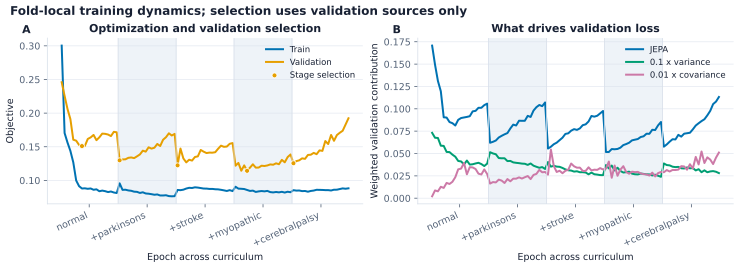

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_training_dynamics.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_training_dynamics.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_training_dynamics.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_training_dynamics.pdf


In [1]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "04",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
